# Divvy EDA: Trips and Station Activity

This notebook reads the dbt models `analytics_dbt.int_trips` and `analytics_dbt.mart_station_activity` and generates trend and station-concentration plots.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine

env_path = Path.cwd() / '.env'
if not env_path.exists():
    env_path = Path.cwd().parent / '.env'
project_root = env_path.parent
images_dir = project_root / 'images'
images_dir.mkdir(exist_ok=True)

load_dotenv(env_path)
db_url = os.getenv('DATABASE_URL')
if not db_url:
    raise RuntimeError('DATABASE_URL not found in .env')

engine = create_engine(db_url)


In [2]:
query = '''
SELECT
  started_date,
  member_casual AS rider_type,
  COUNT(*)::bigint AS trips,
  AVG(duration_seconds) / 60.0 AS avg_trip_minutes
FROM analytics_dbt.int_trips
GROUP BY started_date, member_casual
ORDER BY started_date, rider_type;
'''

df = pd.read_sql(query, engine, parse_dates=['started_date'])
df.head()


,started_date,rider_type,trips,avg_trip_minutes
0,2024-06-30,casual,123,215.015447
1,2024-06-30,member,56,74.578571
2,2024-07-01,casual,7897,24.394131
3,2024-07-01,member,13202,12.825072
4,2024-07-02,casual,8038,22.110363


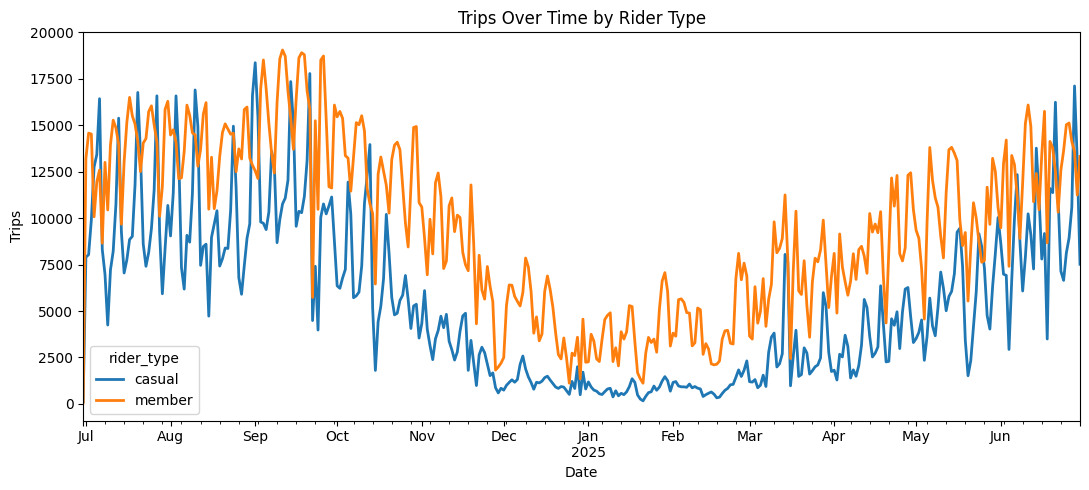

In [3]:
trips_pivot = df.pivot(index='started_date', columns='rider_type', values='trips').fillna(0)

ax = trips_pivot.plot(figsize=(11, 5), linewidth=2)
ax.set_title('Trips Over Time by Rider Type')
ax.set_xlabel('Date')
ax.set_ylabel('Trips')
plt.tight_layout()
plt.savefig(images_dir / 'trips_over_time_by_rider_type.png', bbox_inches='tight')
plt.show()


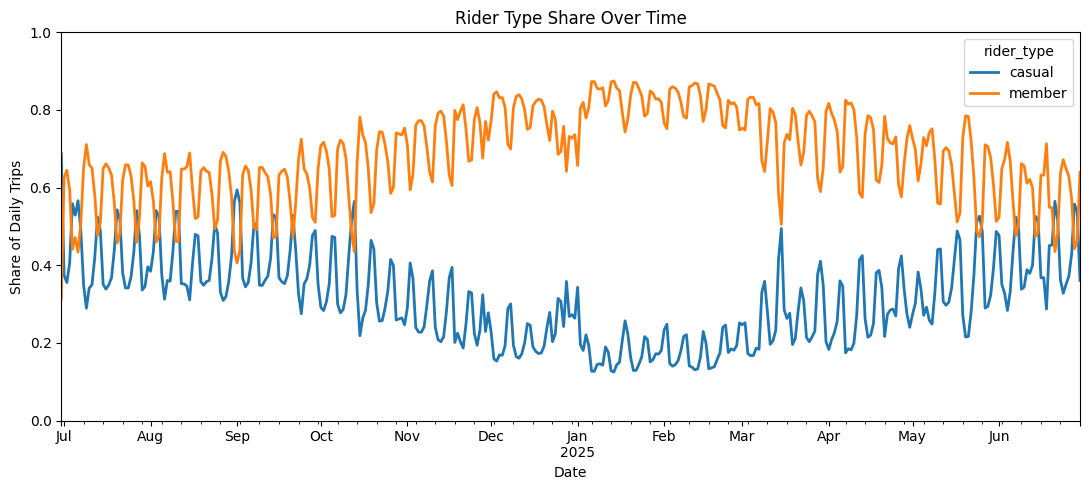

In [4]:
share = trips_pivot.div(trips_pivot.sum(axis=1), axis=0)

ax = share.plot(figsize=(11, 5), linewidth=2)
ax.set_title('Rider Type Share Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Share of Daily Trips')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(images_dir / 'rider_type_share_over_time.png', bbox_inches='tight')
plt.show()


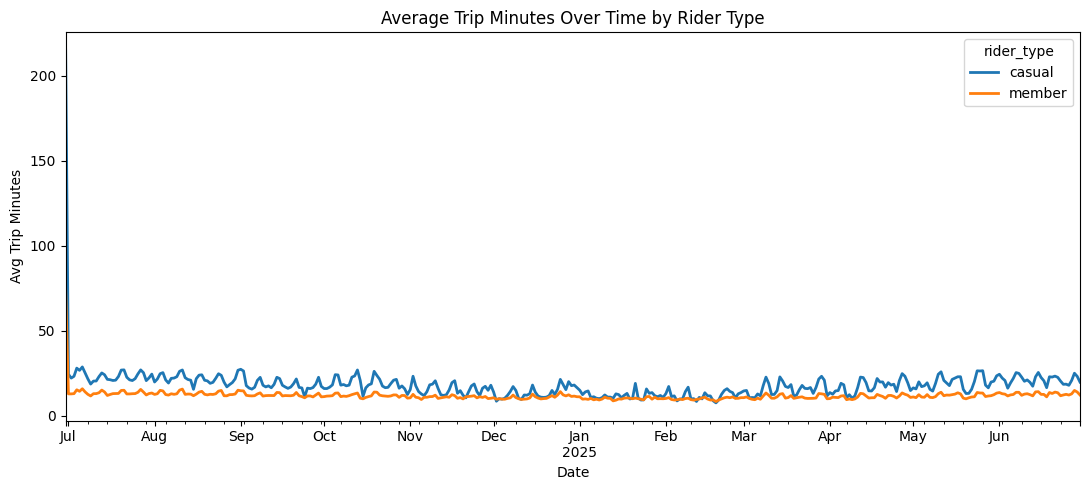

In [5]:
avg_pivot = df.pivot(index='started_date', columns='rider_type', values='avg_trip_minutes')

ax = avg_pivot.plot(figsize=(11, 5), linewidth=2)
ax.set_title('Average Trip Minutes Over Time by Rider Type')
ax.set_xlabel('Date')
ax.set_ylabel('Avg Trip Minutes')
plt.tight_layout()
plt.savefig(images_dir / 'avg_trip_minutes_over_time.png', bbox_inches='tight')
plt.show()


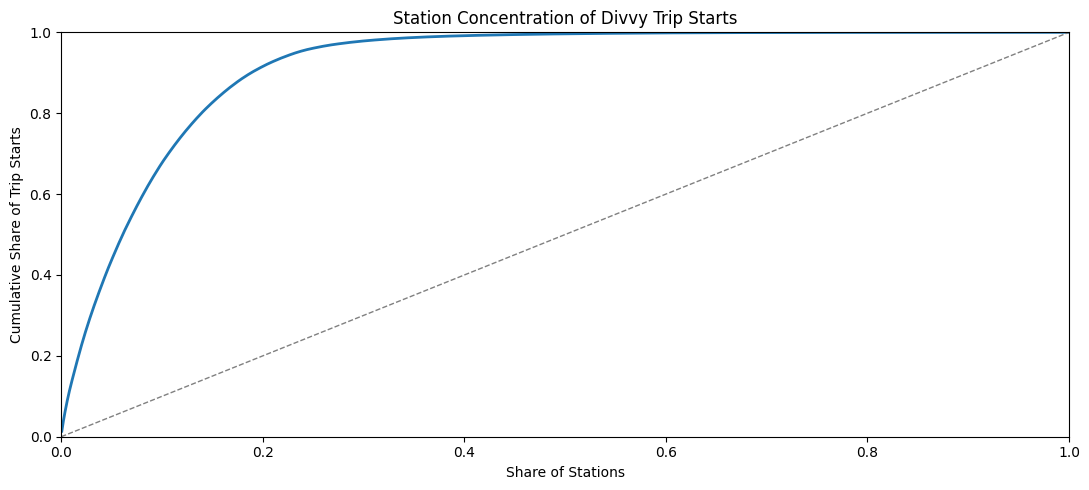

In [6]:
station_query = '''
SELECT
  start_station_name,
  trip_starts AS trips
FROM analytics_dbt.mart_station_activity
ORDER BY trips DESC;
'''

station_concentration = pd.read_sql(station_query, engine)
total_stations = len(station_concentration)

station_concentration['station_rank'] = range(1, total_stations + 1)
station_concentration['trip_share'] = station_concentration['trips'] / station_concentration['trips'].sum()
station_concentration['cumulative_share'] = station_concentration['trip_share'].cumsum()
station_concentration['station_pct'] = station_concentration['station_rank'] / total_stations

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(
    station_concentration['station_pct'],
    station_concentration['cumulative_share'],
    linewidth=2,
)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
ax.set_title('Station Concentration of Divvy Trip Starts')
ax.set_xlabel('Share of Stations')
ax.set_ylabel('Cumulative Share of Trip Starts')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(images_dir / 'station_concentration_of_divvy_trip_starts.png', bbox_inches='tight')
plt.show()


In [7]:
top_10_station_share = station_concentration.loc[
    station_concentration['station_pct'] >= 0.10,
    'cumulative_share',
].iloc[0]
top_20_station_share = station_concentration.loc[
    station_concentration['station_pct'] >= 0.20,
    'cumulative_share',
].iloc[0]

print(f"Top 10% of stations account for {top_10_station_share:.1%} of trip starts.")
print(f"Top 20% of stations account for {top_20_station_share:.1%} of trip starts.")


Top 10% of stations account for 67.7% of trip starts.
Top 20% of stations account for 91.6% of trip starts.
